In [1]:
import numpy as np
import pickle, os 
import matplotlib.pyplot as plt
from py_util_dx.py_utils import setProjectPath

In [2]:
projectPath, mainResultsPath = setProjectPath()

dataset_name = 'MDTB' # or Demand

# defining ROIs
large_ROI = 'PFC'
# large_ROI = 'visual'
# large_ROI = 'somatosensory'
# large_ROI = 'parietal'

resultsPath = os.path.join(mainResultsPath, 'START_B4_parcellation_sanity', dataset_name)
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

output = dict()
PKL_output = os.path.join(resultsPath, f'{dataset_name}_{large_ROI}_output.pkl')

In [3]:
PKL_individualized_parcellation = os.path.join(projectPath, 'results', 'START_A3_bayes_parcellation', dataset_name, f'output_{large_ROI}.pkl')
with open(PKL_individualized_parcellation, 'rb') as pf:
    output_indiv = pickle.load(pf)
    U_indiv_label = output_indiv['indiv_parcellation']  # n_subjects x P
    U_group_label = output_indiv['group_parcellation']
    V = output_indiv['V'].T                             # n_parcels x n_conditions

In [4]:
import sys

np.set_printoptions(threshold=sys.maxsize)

In [5]:
n_subjects, P = U_indiv_label.shape
n_parcels = V.shape[1]

# count the number of parcels for each individual
n_parcels_per_indiv = []
n_vertices_per_parcel = []
for subjI in np.arange(n_subjects):
    vals, counts = np.unique(U_indiv_label[subjI], return_counts=True)
    n_parcels_per_indiv.append(len(vals))
    n_vertices_per_parcel.append(counts) 

n_parcels_per_indiv = np.array(n_parcels_per_indiv)
n_vertices_per_parcel = np.array(n_vertices_per_parcel)

print(n_parcels_per_indiv)
print(n_vertices_per_parcel)

[46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46 46]
[[  106    83   215   379   177   156   189  2125   240    90   112    60
     62   162    65    63   225   315   109  1207    78    76   232    39
     24   111   201    39   102   111   101   346    93    73    96   287
    211   583   190   219    53   255   621  1611   308 47318]
 [  106    71   372   582  2770    91    22    23   111    57   138    13
     17    59    10   546   407   214   157   181   407   177   545   108
    105   115   518   130   263    34    68   111   116    36   162   193
    671   856   377    67   518   121   369   131    55 47318]
 [  106   603   272   195   439    29   163    44   104    13    48    11
    227    77    16   116   196   169   228    91   237   143    54    52
    335   149   463  1918    42    74   111   278  3023    39   102   239
    260   448   153    87    82   193   354   192    25 47318]
 [  106   128   432   244    33   137   114    73   568   146    43    

In [6]:
# load V compute similarity between each pair of parcels
V_simmats = np.corrcoef(V)

Text(0, 0.5, 'parcels')

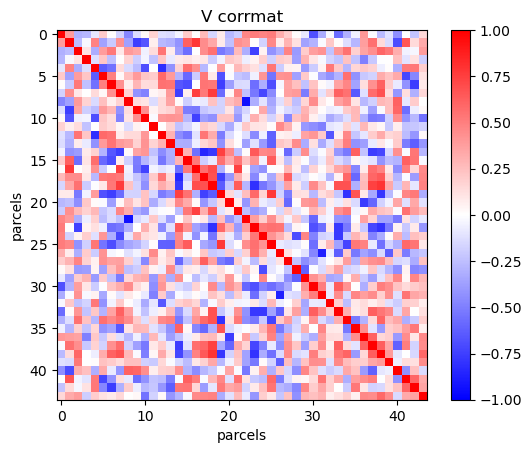

In [7]:
JPG_V_corrmat = os.path.join(resultsPath, f'V_corrmat.jpg')
fig, ax = plt.subplots(1, 1)
im = ax.imshow(V_simmats, cmap='bwr', vmin=-1, vmax=1)
ax.set_aspect('equal')
plt.colorbar(im)
ax.set_title(f'V corrmat')
ax.set_xlabel('parcels')
ax.set_ylabel('parcels')

In [8]:
output['V'] = V
output['V_simmats'] = V_simmats
output['n_parcels_per_indiv'] = n_parcels_per_indiv
output['n_vertices_per_parcel'] = n_vertices_per_parcel

In [9]:
plt.savefig(JPG_V_corrmat, dpi=400, format='jpg')

with open(PKL_output, 'wb') as pf:
    pickle.dump(output, pf)

<Figure size 640x480 with 0 Axes>